In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

Library numpy untuk membantu manipulasi array dan matriks. Library matplotlib.pyplot untuk menampilkan hasil citra ke dalam bentuk visual. library cv2. untuk membaca file gambar, mengubah format warna, melakukan transformasi citra, serta berbagai operasi lain seperti filtering, deteksi objek, dan manipulasi piksel.

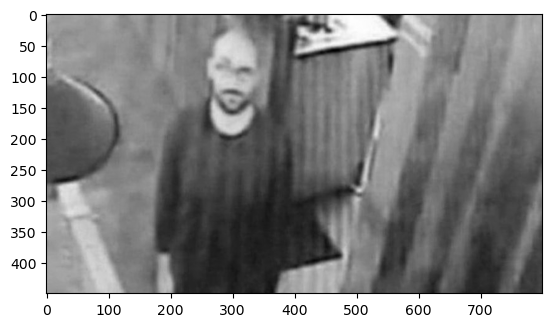

In [41]:
img1 = plt.imread('backup.jpg')
plt.imshow(img1)

img_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

gambar asli dimuat menggunakan fungsi plt.imread dan langsung dikonversi menjadi format grayscale melalui cv2.cvtColor, kemudian ditampilkan dengan imshow dengan warna gray.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

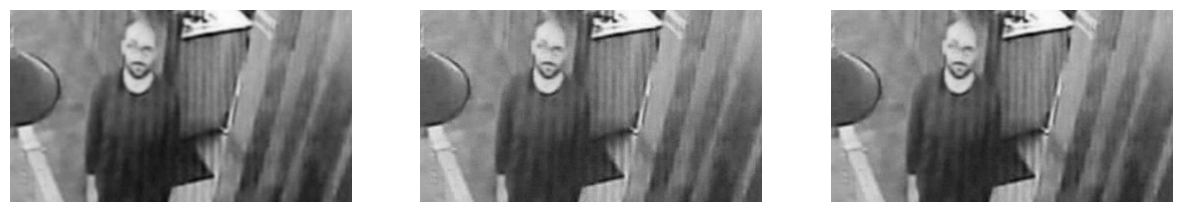

In [3]:
kernelSmoothing = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

smoothing = cv2.filter2D(img_gray, -1, kernelSmoothing)
sharpening = cv2.filter2D(img_gray, -1, kernelSharpening)
smoothing_sharpening = cv2.filter2D(smoothing, -1, kernelSharpening)


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap= 'gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothing_sharpening, cmap='gray')
plt.axis('off')

fungsi konvolusi untuk mencapai dua efek yang berlawanan, yaitu penghalusan (smoothing) dan penajaman (sharpening). Penggunaan kernelSmoothing dengan nilai yang seragam (1/9) berfungsi untuk meratakan intensitas piksel dengan tetangganya, sehingga menghasilkan efek blur yang melembutkan tekstur citra dan sangat efektif untuk mereduksi noise atau bintik halus. Sebaliknya, kernelSharpening bekerja dengan meningkatkan kontras pada transisi intensitas yang tajam untuk mempertegas detail dan tepi objek yang mungkin terlihat kabur pada citra asli.Gambar ketiga, penerapan penajaman setelah citra dihaluskan (smoothing-sharpening) menunjukkan upaya untuk menyeimbangkan kualitas visual, di mana detail yang sempat hilang akibat efek blur dicoba untuk dipulihkan kembali melalui peningkatan kontras lokal.

In [ ]:
def filter(img, size, mode):

    height, width = img.shape

    pad = size // 2

    padded = np.pad(img, pad, mode='edge')

    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':

            area = size * size
            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    
        case 'median':

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    
        case 'modus':

            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = -1
                    mode_val = -1
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

def edge(img, kernelx, kernely):

    gx = convolution(img, kernelx) 

    gy = convolution(img, kernely) 

    canvas = np.abs(gx) + np.abs(gy) 
    
    canvas = canvas * 255.0 / np.max(canvas) 

    return np.clip(canvas, 0, 255).astype(np.uint8) 

Pada fungsi filter, penggunaan teknik sliding window memungkinkan manipulasi kualitas citra melalui filter statistik. Filter mean bekerja dengan menghitung rata-rata nilai dalam jendela untuk menghaluskan atau memburamkan citra guna mereduksi noise , sementara filter median mengambil nilai tengah dari kumpulan piksel yang telah diurutkan untuk membersihkan bintik tajam tanpa merusak ketajaman tepi objek. Filter modus secara unik mencari nilai yang paling sering muncul dalam kernel, yang memberikan efek visual menyerupai poster karena penyeragaman warna dominan pada area lokal. Penggunaan np.pad(img, pad, mode='edge') sangat krusial di sini untuk mempertahankan dimensi citra asli dan mencegah kesalahan perhitungan saat jendela pemroses berada di batas paling luar gambar.fungsi edge mengimplementasikan algoritma deteksi tepi dengan menggabungkan perubahan intensitas dari dua arah yang berbeda. Fungsi ini memanggil proses konvolusi secara horizontal (gx) dan vertikal (gy) menggunakan kernel spesifik seperti Sobel atau Prewitt untuk menangkap gradien kecerahan. Langkah penggabungan dilakukan menggunakan penjumlahan nilai absolut np.abs(gx) + np.abs(gy) untuk memastikan bahwa setiap transisi warna, baik dari gelap ke terang maupun sebaliknya, tetap bernilai positif dan terdeteksi sebagai garis tepi. Sebagai tahap akhir, dilakukan normalisasi canvas * 255.0 / np.max(canvas) untuk memetakan kembali hasil perhitungan ke rentang standar piksel 0-255

C:\Users\Dell\AppData\Local\Temp\ipykernel_20884\1527410275.py:64: RuntimeWarning: invalid value encountered in divide
  canvas = canvas * 255.0 / np.max(canvas)
C:\Users\Dell\AppData\Local\Temp\ipykernel_20884\1527410275.py:67: RuntimeWarning: invalid value encountered in cast
  return np.clip(canvas, 0, 255).astype(np.uint8)


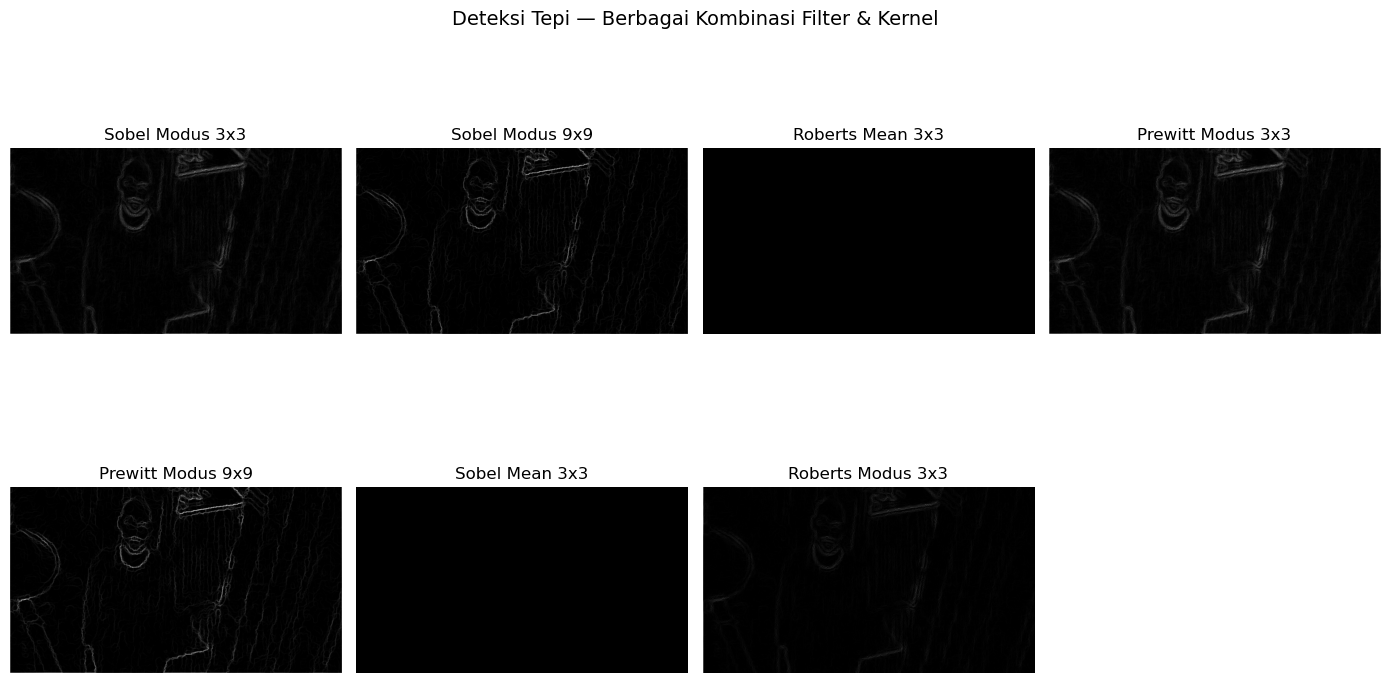

In [60]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

robertsX = np.array([
    [ 1,  0],
    [ 0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0,  1],
    [-1, 0]
], dtype=np.float32)

modus_3x3  = filter(img_gray, 3, 'modus')
modus_9x9  = filter(img_gray, 9, 'modus')
mean_3x3   = filter(img_gray, 3, 'mean')


sobel_modus_3x3   = edge(modus_3x3,  sobelX,   sobelY)
sobel_modus_9x9   = edge(modus_9x9,  sobelX,   sobelY)
roberts_mean_3x3  = edge(mean_3x3,   robertsX,  robertsY)
prewitt_modus_3x3 = edge(modus_3x3,  prewittX,  prewittY)
prewitt_modus_9x9 = edge(modus_9x9,  prewittX,  prewittY)
sobel_mean_3x3    = edge(mean_3x3,   sobelX,    sobelY)
roberts_modus_3x3 = edge(modus_3x3,  robertsX,  robertsY)

plt.figure(figsize=(14, 8))

plt.subplot(2, 4, 1)
plt.imshow(sobel_modus_3x3, cmap='gray')
plt.title('Sobel Modus 3x3')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobel_modus_9x9, cmap='gray')
plt.title('Sobel Modus 9x9')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(roberts_mean_3x3, cmap='gray')
plt.title('Roberts Mean 3x3')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewitt_modus_3x3, cmap='gray')
plt.title('Prewitt Modus 3x3')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewitt_modus_9x9, cmap='gray')
plt.title('Prewitt Modus 9x9')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobel_mean_3x3, cmap='gray')
plt.title('Sobel Mean 3x3')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(roberts_modus_3x3, cmap='gray')
plt.title('Roberts Modus 3x3')
plt.axis('off')

plt.suptitle('Deteksi Tepi — Berbagai Kombinasi Filter & Kernel', fontsize=14)
plt.tight_layout()
plt.show()

Penggunaan filter modus sebelum deteksi tepi berfungsi menyederhanakan area warna menjadi blok-blok dominan yang efektif menghilangkan bintik noise, sementara filter mean memberikan efek penghalusan yang lebih merata sehingga menghasilkan garis tepi yang cenderung lebih lembut. Perbedaan ukuran kernel antara 3x3 dan 9x9 memberikan dampak visual yang signifikan, di mana kernel 9x9 menyebabkan hilangnya detail halus pada gambar karakter akibat efek blur yang ekstrem.Operator Sobel menghasilkan garis yang lebih tebal dan stabil karena memiliki pembobotan lebih besar pada titik pusat yang membuatnya lebih tahan terhadap noise dibandingkan Prewitt. Di sisi lain, operator Roberts menghasilkan garis tepi yang paling tipis karena ukuran matriksnya yang kecil ($2\times2$), namun menjadi sangat sensitif terhadap gangguan. Seluruh proses ini mengandalkan penjumlahan absolut dalam fungsi edge untuk memastikan transisi intensitas dari gelap ke terang maupun sebaliknya tetap bernilai positif

In [59]:
prewitt_tepi = edge(img_backup_gray, prewittX, prewittY)
sobel_tepi = edge(img_backup_gray, sobelX, sobelY)
roberts_tepi = edge(img_backup_gray, robertsX, robertsY)
prewitt_sobel_tepi = edge(prewitt_tepi, sobelX, sobelY)
prewitt_roberts_tepi = edge(prewitt_tepi, robertsX, robertsY)
sobel_roberts_tepi = edge(sobel_tepi, robertsX, robertsY)
prewitt_sobel_roberts_tepi = edge(prewitt_tepi, sobelX, sobelY) + edge(prewitt_tepi, robertsX, robertsY)

plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(prewitt_tepi, cmap='gray')
plt.title('Prewitt')
plt.subplot(2,4,2)
plt.imshow(sobel_tepi, cmap='gray')
plt.title('Sobel')
plt.subplot(2,4,3)
plt.imshow(roberts_tepi, cmap='gray')
plt.title('Roberts')
plt.subplot(2,4,4)
plt.imshow(prewitt_sobel_tepi, cmap='gray')
plt.title('Prewitt + Sobel')
plt.subplot(2,4,5)
plt.imshow(prewitt_roberts_tepi, cmap='gray')
plt.title('Prewitt + Roberts')
plt.subplot(2,4,6)
plt.imshow(sobel_roberts_tepi, cmap='gray')
plt.title('Sobel + Roberts')
plt.subplot(2,4,7)
plt.imshow(prewitt_sobel_roberts_tepi, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')

NameError: name 'img_backup_gray' is not defined

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

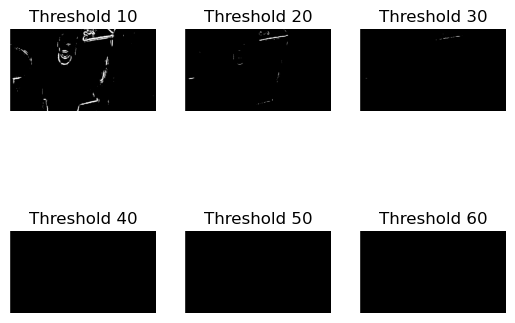

In [8]:
nilai_threshold = 10
thresh_img = np.zeros_like(img_gray)
thresh_img[roberts_tepi > nilai_threshold] = 255
thresh_img[roberts_tepi < nilai_threshold] = 0

nilai_threshold = 20
thresh_img2 = np.zeros_like(img_gray)
thresh_img2[roberts_tepi > nilai_threshold] = 255
thresh_img2[roberts_tepi < nilai_threshold] = 0

nilai_threshold = 30
thresh_img3 = np.zeros_like(img_gray)
thresh_img3[roberts_tepi > nilai_threshold] = 255
thresh_img3[roberts_tepi < nilai_threshold] = 0

nilai_threshold = 40
thresh_img4 = np.zeros_like(img_gray)
thresh_img4[roberts_tepi > nilai_threshold] = 255
thresh_img4[roberts_tepi < nilai_threshold] = 0

nilai_threshold = 50
thresh_img5 = np.zeros_like(img_gray)
thresh_img5[roberts_tepi > nilai_threshold] = 255
thresh_img5[roberts_tepi < nilai_threshold] = 0

nilai_threshold = 60
thresh_img6 = np.zeros_like(img_gray)
thresh_img6[roberts_tepi > nilai_threshold] = 255
thresh_img6[roberts_tepi < nilai_threshold] = 0

plt.Figure(figsize=(16, 8))
plt.subplot(2,3,1)
plt.imshow(thresh_img, cmap ="gray" )
plt.title("Threshold 10")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(thresh_img2, cmap ="gray")
plt.title("Threshold 20")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(thresh_img3, cmap="gray")
plt.title("Threshold 30")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(thresh_img4, cmap ="gray")
plt.title("Threshold 40")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(thresh_img5, cmap ="gray")
plt.title("Threshold 50")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(thresh_img6, cmap="gray" )
plt.title("Threshold 60")
plt.axis('off')

menunjukkan proses Thresholding (pengambangan) yang diterapkan pada hasil deteksi tepi Roberts untuk memisahkan objek utama dari background berdasarkan nilai intensitas piksel tertentu. Secara teknis, proses ini mengubah citra grayscale menjadi citra biner (hitam-putih), di mana setiap piksel yang nilainya melebihi ambang batas (nilai_threshold) akan diubah menjadi putih (255) sebagai representasi tepi, sedangkan yang di bawahnya akan menjadi hitam (0).semakin rendah nilai threshold (seperti pada angka 10), maka semakin banyak detail dan noise kecil yang tertangkap, sebaliknya, saat nilai threshold ditingkatkan hingga ke angka 60, citra menjadi jauh lebih bersih dari gangguan noise.

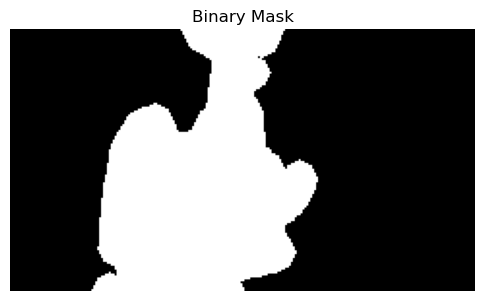

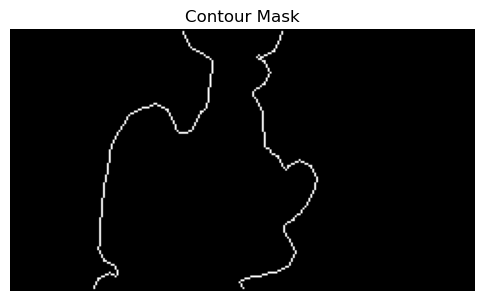

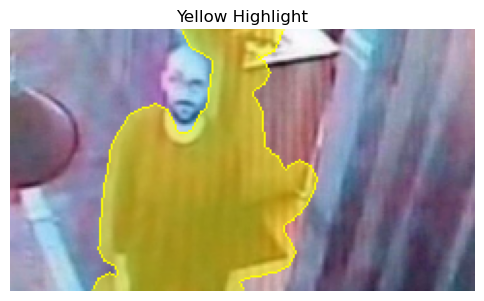

In [61]:
scale           = 0.3
img_small_color = cv2.resize(img1,
                             (int(img1.shape[1] * scale),
                              int(img1.shape[0] * scale)))
img_small_gray  = cv2.cvtColor(img_small_color, cv2.COLOR_BGR2GRAY)

def generate_binary_mask(img_gray):
    kernel_blur = np.array([
        [1, 4,  6,  4,  1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1, 4,  6,  4,  1]
    ], dtype=np.float32) / 256.0

    height, width = img_gray.shape
    pad     = 2
    padded  = np.pad(img_gray, pad, mode='constant')
    blurred = np.zeros_like(img_gray, dtype=np.float32)
    for i in range(height):
        for j in range(width):
            region       = padded[i:i+5, j:j+5]
            blurred[i,j] = np.sum(region * kernel_blur)
    blurred = blurred.astype(np.uint8)

    hist  = np.zeros(256, dtype=np.float32)
    total = height * width
    for val in blurred.ravel():
        hist[val] += 1
    hist /= total

    best_thresh = 0
    best_var    = 0.0
    for t in range(1, 256):
        w0 = np.sum(hist[:t])
        w1 = np.sum(hist[t:])
        if w0 == 0 or w1 == 0:
            continue
        mu0 = np.sum(np.arange(t)     * hist[:t]) / w0
        mu1 = np.sum(np.arange(t,256) * hist[t:]) / w1
        var = w0 * w1 * (mu0 - mu1) ** 2
        if var > best_var:
            best_var    = var
            best_thresh = t

    mask_normal = np.where(blurred >  best_thresh, 255, 0).astype(np.uint8)
    mask_invert = np.where(blurred <= best_thresh, 255, 0).astype(np.uint8)

    if np.sum(mask_normal == 255) < np.sum(mask_invert == 255):
        mask = mask_normal
    else:
        mask = mask_invert

    se = np.zeros((7, 7), dtype=np.uint8)
    for y in range(7):
        for x in range(7):
            if (x-3)**2 + (y-3)**2 <= 9:
                se[y, x] = 1

    def dilate_manual(img, se):
        kh, kw = se.shape
        ph, pw = kh//2, kw//2
        padded = np.pad(img, ((ph,ph),(pw,pw)), mode='constant')
        out    = np.zeros_like(img)
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                region   = padded[i:i+kh, j:j+kw]
                out[i,j] = 255 if np.any(region[se==1] == 255) else 0
        return out

    def erode_manual(img, se):
        kh, kw = se.shape
        ph, pw = kh//2, kw//2
        padded = np.pad(img, ((ph,ph),(pw,pw)), mode='constant', constant_values=255)
        out    = np.zeros_like(img)
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                region   = padded[i:i+kh, j:j+kw]
                out[i,j] = 255 if np.all(region[se==1] == 255) else 0
        return out

    def closing_manual(img, se, iterations=1):
        result = img.copy()
        for _ in range(iterations):
            result = dilate_manual(result, se)
            result = erode_manual(result, se)
        return result

    def opening_manual(img, se, iterations=1):
        result = img.copy()
        for _ in range(iterations):
            result = erode_manual(result, se)
            result = dilate_manual(result, se)
        return result

    mask = closing_manual(mask, se, iterations=3)
    mask = opening_manual(mask, se, iterations=2)
    mask = dilate_manual(mask, se)
    mask = dilate_manual(mask, se)

    visited    = np.zeros_like(mask, dtype=bool)
    components = {}
    label_id   = 0

    for i in range(height):
        for j in range(width):
            if mask[i, j] == 255 and not visited[i, j]:
                queue         = [(i, j)]
                visited[i, j] = True
                pixels        = []
                while queue:
                    ci, cj = queue.pop(0)
                    pixels.append((ci, cj))
                    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                        ni, nj = ci+di, cj+dj
                        if 0<=ni<height and 0<=nj<width:
                            if mask[ni,nj]==255 and not visited[ni,nj]:
                                visited[ni,nj] = True
                                queue.append((ni, nj))
                label_id += 1
                components[label_id] = pixels

    clean_mask = np.zeros_like(mask)
    if components:
        largest_label = max(components, key=lambda k: len(components[k]))
        for (pi, pj) in components[largest_label]:
            clean_mask[pi, pj] = 255

    return clean_mask

def generate_contour_mask(img_gray):
    binary_mask   = generate_binary_mask(img_gray)
    height, width = binary_mask.shape
    contour_img   = np.zeros_like(binary_mask)

    for i in range(1, height-1):
        for j in range(1, width-1):
            if binary_mask[i, j] == 255:
                neighbors = [
                    binary_mask[i-1, j], binary_mask[i+1, j],
                    binary_mask[i, j-1], binary_mask[i, j+1]
                ]
                if 0 in neighbors:
                    contour_img[i, j] = 255

    return contour_img

def generate_yellow_highlight(img_gray, img_color, alpha=0.5):
    binary_mask   = generate_binary_mask(img_gray)
    height, width = binary_mask.shape
    output        = img_color.copy()

    for i in range(height):
        for j in range(width):
            if binary_mask[i, j] == 255:
                b, g, r = img_color[i, j]
                output[i, j, 0] = int(b * (1 - alpha) + 0   * alpha)
                output[i, j, 1] = int(g * (1 - alpha) + 255 * alpha)
                output[i, j, 2] = int(r * (1 - alpha) + 255 * alpha)

    contour_mask = generate_contour_mask(img_gray)
    for i in range(height):
        for j in range(width):
            if contour_mask[i, j] == 255:
                output[i, j] = [0, 255, 255]

    return output

binary_mask  = generate_binary_mask(img_small_gray)
contour_mask = generate_contour_mask(img_small_gray)
highlight    = generate_yellow_highlight(img_small_gray, img_small_color)

plt.figure(figsize=(6, 5))
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary Mask')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(contour_mask, cmap='gray')
plt.title('Contour Mask')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(highlight, cv2.COLOR_BGR2RGB))
plt.title('Yellow Highlight')
plt.axis('off')
plt.show()

Proses dimulai dengan reduksi noise menggunakan filter Gaussian manual dan penentuan ambang batas dinamis. fungsi generate_contour_mask mengekstraksi garis tepi objek dengan memeriksa tetangga setiap piksel pada masker biner; jika sebuah piksel putih dikelilingi oleh setidaknya satu piksel hitam, maka piksel tersebut ditandai sebagai kontur, hasil akhir berupa yellow_highlight di mana area objek diberikan nuansa warna kuning transparan sementara garis konturnya ditegaskan dengan warna kuning solid.

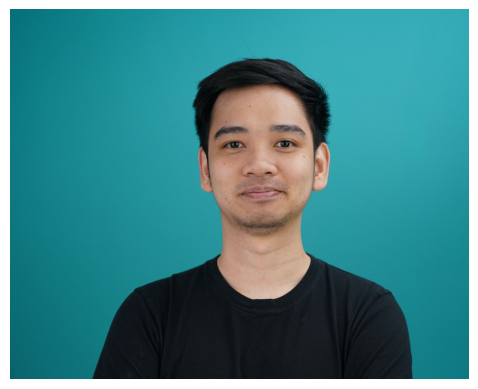

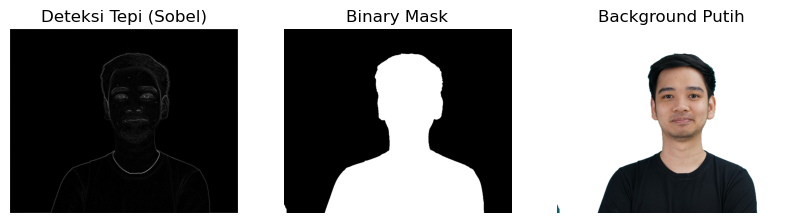

In [ ]:
img2 = plt.imread('david.jpg')
plt.imshow(img2)
plt.axis('off')
plt.show()

img_gray = (0.299 * img2[:,:,0] +
            0.587 * img2[:,:,1] +
            0.114 * img2[:,:,2]).astype(np.uint8)

def convolution(img, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(img, pad_size, mode='constant')
    canvas   = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region       = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx     = convolution(img, kernelx)
    gy     = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
sobelY = np.array([[ 1,2,1],[ 0,0,0],[-1,-2,-1]], dtype=np.float32)

def mask_background_toska(img):
    height, width = img.shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            r = int(img[i, j, 0])
            g = int(img[i, j, 1])
            b = int(img[i, j, 2])

            is_toska = (g > 100 and b > 100 and
                        g > r + 30 and b > r + 20)

            if not is_toska:
                mask[i, j] = 255

    pad     = 1
    padded  = np.pad(mask, pad, mode='edge')
    cleaned = np.zeros_like(mask)
    for i in range(height):
        for j in range(width):
            region        = padded[i:i+3, j:j+3].ravel()
            values        = np.sort(region)
            cleaned[i, j] = values[len(values) // 2]

    return cleaned

def apply_mask_white_bg(img, binary_mask):
    height, width = binary_mask.shape
    output = np.ones_like(img) * 255

    for i in range(height):
        for j in range(width):
            if binary_mask[i, j] == 255:
                output[i, j] = img[i, j]

    return output

binary_mask = mask_background_toska(img2)
hasil_mask  = apply_mask_white_bg(img2, binary_mask)

plt.figure(figsize=(10, 5))
plt.subplot(1,3,1)
plt.imshow(hasil_tepi, cmap='gray')
plt.title('Deteksi Tepi (Sobel)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary Mask')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_mask)
plt.title('Background Putih')
plt.axis('off')
plt.show()

Dimulai dengan konversi citra ke grayscale menggunakan pembobotan standar luminans (0.299R + 0.587G + 0.114B), yang kemudian diproses melalui fungsi edge menggunakan operator Sobel.Selanjutnya, fungsi mask_background_toska melakukan segmentasi berbasis warna dengan mengevaluasi setiap piksel untuk mendeteksi area latar belakang berwarna toska melalui logika perbandingan kanal Hijau (Green) dan Biru (Blue) terhadap Merah (Red). Area yang tidak termasuk dalam kategori warna toska ditandai sebagai objek (putih), yang kemudian dibersihkan menggunakan filter Median manual untuk menghilangkan bintik-bintik noise ( salt-and-pepper) yang sering muncul saat pemrosesan warna mentah. Hasil akhirnya adalah binary_mask yang bersih, yang kemudian digunakan oleh fungsi apply_mask_white_bg sebagai referensi spasial untuk memetakan piksel objek asli ke kanvas putih baru.

Kesimpulan
Perbaikan kualitas citra melalui filter statistik seperti mean, median, dan modus, serta teknik konvolusi untuk penghalusan dan penajaman, berperan sebagai tahap prapemrosesan yang krusial untuk mengondisikan citra agar bebas dari noise dan memiliki detail yang lebih tegas. Proses ini bekerja dengan cara merekayasa nilai intensitas warna lokal, di mana penggunaan padding menjadi sangat penting untuk menjaga integritas dimensi citra dan mencegah terjadinya kegagalan komputasi pada area tepi gambar.
Di sisi lain, deteksi tepi menggunakan operator gradien seperti Sobel, Prewitt, dan Roberts berfungsi untuk mengekstraksi fitur struktural dengan cara mengidentifikasi perubahan intensitas yang drastis sebagai representasi batas objek. Karakteristik kontur yang dihasilkan sangat bergantung pada jenis operator dan ukuran kernel yang digunakan, di mana operator Sobel cenderung lebih stabil terhadap gangguan dibandingkan Roberts yang sangat sensitif namun menghasilkan garis yang sangat tipis.
Penerapan thresholding dan operasi morfologi seperti opening dan closing menyempurnakan hasil pengolahan dengan mengubah citra menjadi format biner yang bersih dari artefak kecil. Melalui integrasi seluruh teknik ini, kita dapat melakukan segmentasi objek secara otomatis dan memberikan penekanan visual (highlight) pada fitur-fitur penting dalam citra.